In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
# import pyfolio as pf
import quantstats as qs

In [3]:
RISKY_ASSETS = ['NVDA', 'MSFT', 'GOOG', 'AMZN', 'TSLA']
START_DATE = '2020-01-01'
END_DATE = '2023-01-01'

n_assets = len(RISKY_ASSETS)

In [7]:
prices_df.Close

Ticker,AMZN,GOOG,MSFT,NVDA,TSLA
Date,,,,,
2020-01-02,94.900497,67.903816,152.791107,5.971410,28.684000
2020-01-03,93.748497,67.570587,150.888596,5.875831,29.534000
2020-01-06,95.143997,69.236694,151.278641,5.900473,30.102667
2020-01-07,95.343002,69.193497,149.899338,5.971909,31.270666
2020-01-08,94.598503,69.738754,152.286942,5.983109,32.809334
...,...,...,...,...,...
2022-12-23,85.250000,89.199577,233.591843,15.191639,123.150002
2022-12-27,83.040001,87.332367,231.859985,14.107664,109.099998
2022-12-28,81.820000,85.872353,229.482254,14.022744,112.709999


In [8]:
prices_df = yf.download(RISKY_ASSETS, START_DATE, END_DATE)

returns = prices_df['Close'].pct_change().dropna()

portfolio_weights = n_assets * [1 / n_assets]

portfolio_returns = pd.Series(np.dot(portfolio_weights, returns.T), index=returns.index)

C:\Users\yunis\AppData\Local\Temp\ipykernel_11460\2182827896.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices_df = yf.download(RISKY_ASSETS, START_DATE, END_DATE)
[*********************100%***********************]  5 of 5 completed


In [12]:
returns

Ticker,AMZN,GOOG,MSFT,NVDA,TSLA
Date,,,,,
2020-01-03,-0.012139,-0.004907,-0.012452,-0.016006,0.029633
2020-01-06,0.014886,0.024657,0.002585,0.004194,0.019255
2020-01-07,0.002092,-0.000624,-0.009118,0.012107,0.038801
2020-01-08,-0.007809,0.007880,0.015928,0.001876,0.049205
2020-01-09,0.004799,0.011045,0.012493,0.010982,-0.021945
...,...,...,...,...,...
2022-12-23,0.017425,0.017562,0.002267,-0.008671,-0.017551
2022-12-27,-0.025924,-0.020933,-0.007414,-0.071353,-0.114089
2022-12-28,-0.014692,-0.016718,-0.010255,-0.006019,0.033089


In [11]:
portfolio_returns

Date
2020-01-03   -0.003174
2020-01-06    0.013115
2020-01-07    0.008651
2020-01-08    0.013416
2020-01-09    0.003475
                ...   
2022-12-23    0.002206
2022-12-27   -0.047943
2022-12-28   -0.002919
2022-12-29    0.041299
2022-12-30    0.000474
Length: 755, dtype: float64

                           Strategy
-------------------------  ----------
Start Period               2020-01-03
End Period                 2022-12-30
Risk-Free Rate             0.0%
Time in Market             100.0%

Cumulative Return          105.34%
CAGR﹪                     27.14%

Sharpe                     0.81
Prob. Sharpe Ratio         91.75%
Smart Sharpe               0.72
Sortino                    1.15
Smart Sortino              1.02
Sortino/√2                 0.81
Smart Sortino/√2           0.72
Omega                      1.15

Max Drawdown               -51.11%
Max DD Date                2022-12-28
Max DD Period Start        2021-11-22
Max DD Period End          2022-12-30
Longest DD Days            404
Volatility (ann.)          39.22%
Calmar                     0.53
Skew                       -0.31
Kurtosis                   2.41

Expected Daily %           0.1%
Expected Monthly %         2.02%
Expected Yearly %          27.1%
Kelly Criterion            7.26%
Risk of Ruin

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2021-11-22,2022-12-28,2022-12-30,404,-51.107338,-49.063996
2,2020-02-20,2020-03-18,2020-05-08,79,-34.477453,-34.037125
3,2021-02-09,2021-03-08,2021-04-09,60,-15.554485,-12.476268
4,2020-09-03,2020-09-08,2020-11-24,83,-15.496604,-14.841400
5,2021-04-16,2021-05-13,2021-06-10,56,-10.630490,-10.495829


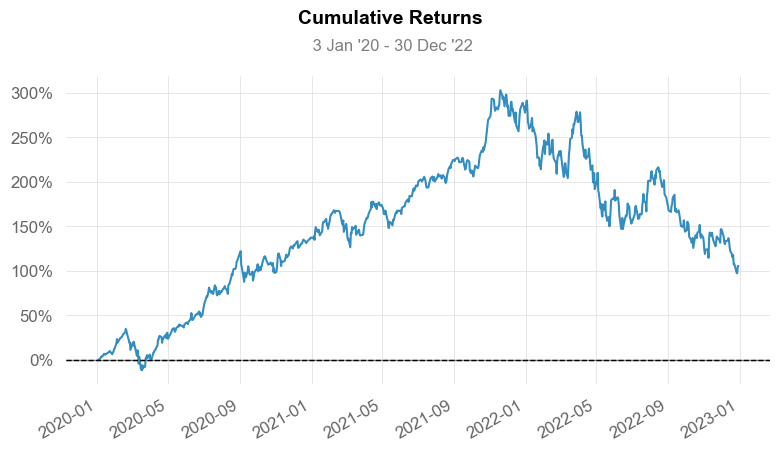

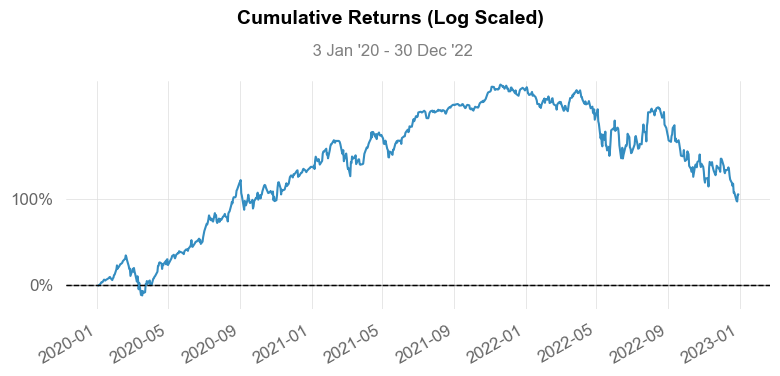

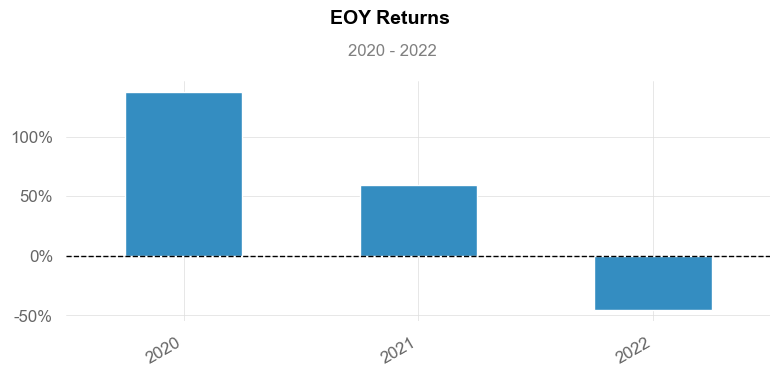

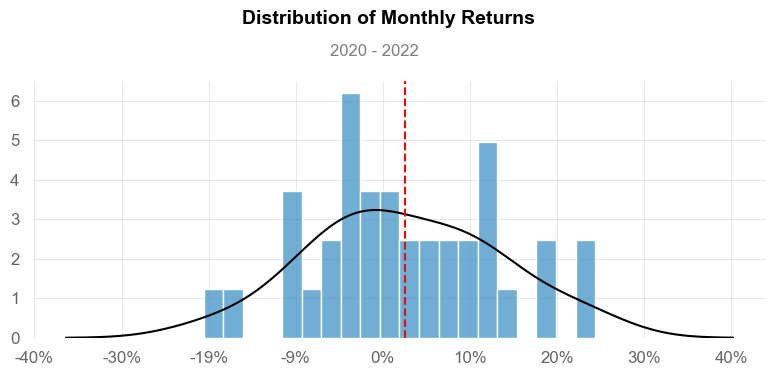

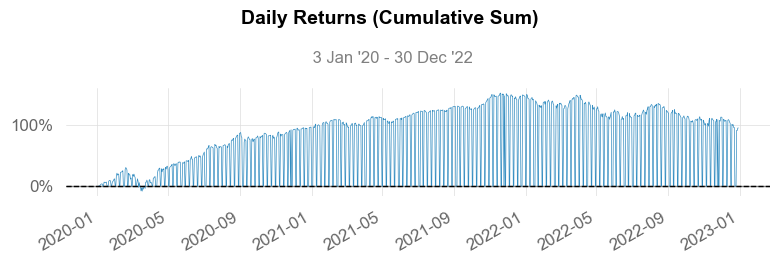

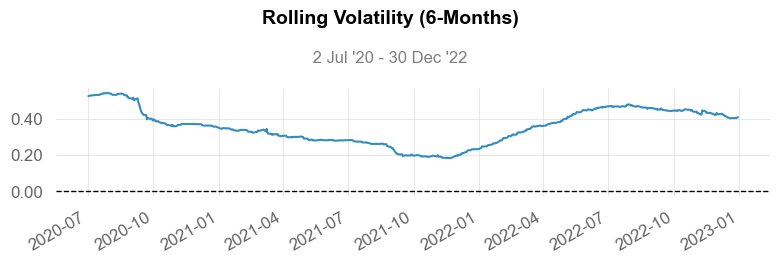

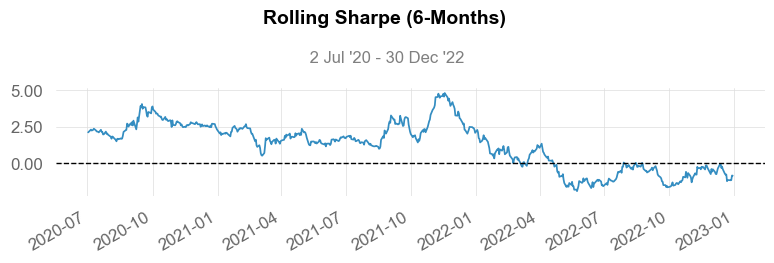

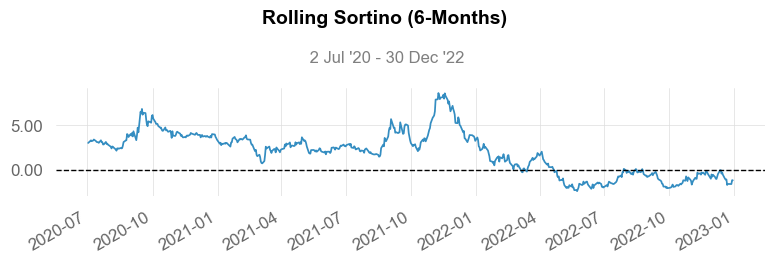

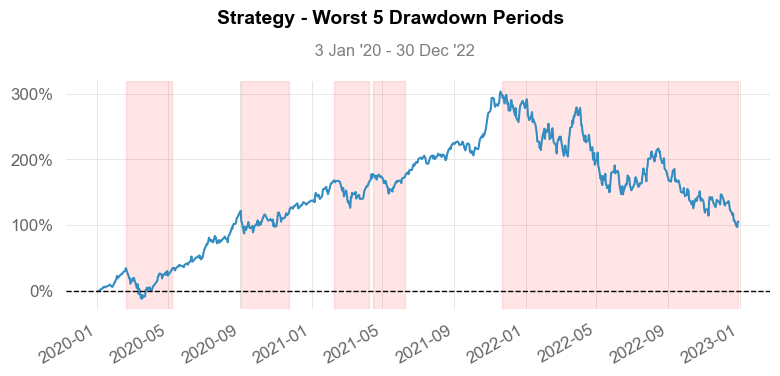

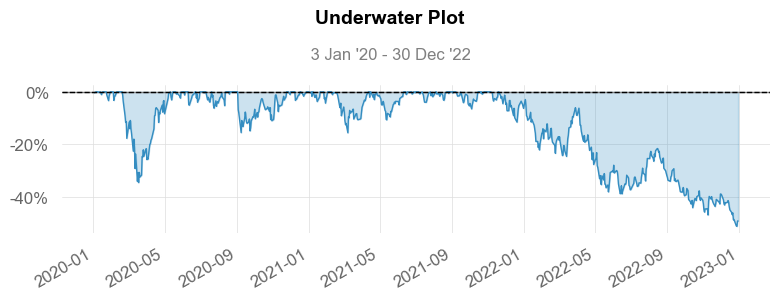

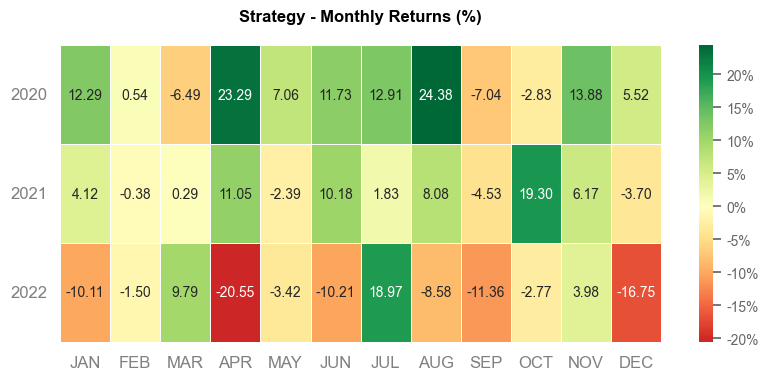

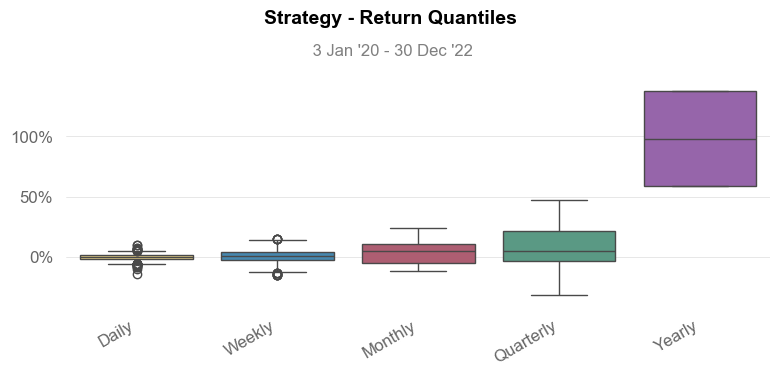

In [9]:
qs.reports.full(portfolio_returns, benchmark=None, mode='daily', annualize=True)

# Efficient Frontier

In [13]:
N_PORTFOLIOS = 10 ** 5
N_DAYS = 252
RISKY_ASSETS = ['NVDA', 'MSFT', 'GOOG', 'AMZN', 'TSLA']
RISKY_ASSETS.sort()
START_DATE = '2020-01-01'
END_DATE = '2021-01-01'

n_assets = len(RISKY_ASSETS)

In [14]:
prices_df = yf.download(RISKY_ASSETS, START_DATE, END_DATE)

C:\Users\yunis\AppData\Local\Temp\ipykernel_11460\2010141508.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices_df = yf.download(RISKY_ASSETS, START_DATE, END_DATE)
[*********************100%***********************]  5 of 5 completed


In [ ]:
# 연납화 평균 수익률과 해당 표준편차를 계산한다.
# 연납화 평균 수익률 : 일별 수익률을 연별로 변환하는 과정 -> 평균 수익률 * 일 수
# 표준편차 : 수익률의 변동성을 측정하는 지표

returns_df = prices_df['Close'].pct_change().dropna()
avg_returns = returns_df.mean() * N_DAYS
cov_mat = returns_df.cov() * N_DAYS

cov_mat

Ticker,AMZN,GOOG,MSFT,NVDA,TSLA
Ticker,,,,,
AMZN,0.148310,0.100376,0.124965,0.148669,0.158086
GOOG,0.100376,0.146974,0.143595,0.166978,0.153705
MSFT,0.124965,0.143595,0.193066,0.214268,0.198492
NVDA,0.148669,0.166978,0.214268,0.335382,0.266729
TSLA,0.158086,0.153705,0.198492,0.266729,0.800330


weights = np.random.random(size=(N_PORTFOLIOS, n_assets))

weights라는 NumPy 배열을 생성합니다.

np.random.random(): 0.0 이상 1.0 미만의 균등 분포 난수를 생성하는 함수입니다.

size=(N_PORTFOLIOS, n_assets): 배열의 크기를 지정합니다. N_PORTFOLIOS 행과 n_assets 열을 가진 2차원 배열이 만들어집니다. 각 행은 하나의 포트폴리오를, 각 열은 해당 포트폴리오 내의 하나의 자산을 나타냅니다.

weights /= np.sum(weights, axis=1)[:, np.newaxis]

생성된 가중치(weights)를 정규화하여 각 포트폴리오의 비중 합이 1이 되도록 만듭니다.

np.sum(weights, axis=1): weights 배열의 각 행(axis=1)에 있는 원소들을 합산합니다.

[:, np.newaxis]: 합산 결과는 1차원 배열인데, 이를 2차원 열 벡터로 변환하는 트릭입니다.

weights /= ...: 변환된 열 벡터를 원래의 weights 배열에 나눠줍니다. 이 과정에서 NumPy의 브로드캐스팅(broadcasting) 기능이 사용되어 각 행이 자신의 총합으로 나누어집니다.

In [ ]:
# 5. 랜덤 포트폴리오 가중치를 시뮬레이션한다.

np.random.seed(42)
weights = np.random.random(size=(N_PORTFOLIOS, n_assets))
weights /= np.sum(weights, axis=1)[:, np.newaxis]
weights

array([[0.13319703, 0.33810082, 0.26031769, 0.21289984, 0.05548463],
       [0.06528492, 0.02430844, 0.36250145, 0.25157131, 0.29633388],
       [0.00928442, 0.43746759, 0.37546445, 0.09577331, 0.08201023],
       ...,
       [0.20159568, 0.1276073 , 0.23897949, 0.25821686, 0.17360066],
       [0.06162576, 0.23687072, 0.20328404, 0.22043154, 0.27778794],
       [0.19378302, 0.288101  , 0.14201812, 0.19362775, 0.18247011]],
      shape=(100000, 5))

In [ ]:
# 6. 포트폴리오 지표 계산

# 가중치 * 평균 수익률
# weights : 랜덤하게 만든 2차원 표, 각 행은 하나의 포트폴리오 비중이고 열은 각 자산의 비율. 각 행의 합은 1
portf_rtns = np.dot(weights, avg_returns)

portf_vol = []

for i in range(0, len(weights)):
    portf_vol.append(np.sqrt(np.dot(weights[i].T, np.dot(cov_mat, weights[i]))))
    
portf_vol = np.array(portf_vol)
portf_sharpe_ratio = portf_rtns / portf_vol

In [ ]:
# 7. 모든 데이터를 가진 DF 생성
portf_results_df = pd.DataFrame({'returns' : portf_rtns,
                                 'volatility' : portf_vol,
                                 'sharpe_ratio' : portf_sharpe_ratio})

portf_results_df

,returns,volatility,sharpe_ratio
0,0.644578,0.411733,1.565525
1,1.188244,0.512942,2.316526
2,0.605770,0.412341,1.469099
3,0.909951,0.453608,2.006032
4,1.093778,0.460789,2.373703
...,...,...,...
99995,0.935624,0.437870,2.136759
99996,0.561148,0.406977,1.378820
99997,0.949558,0.450640,2.107133
99998,1.109263,0.485937,2.282730


In [ ]:
# 8. 효율적 경계선을 생성하는 점 알아내기

N_POINTS = 100
portf_vol_ef = []
indices_to_skip = []

portf_rtns_ef = np.linspace(portf_results_df.returns.min(),
                            portf_results_df.returns.max(),
                            N_POINTS)

portf_rtns_ef = np.round(portf_rtns_ef, 2)
portf_rtns = np.round(portf_rtns, 2)

for point_index in range(N_POINTS):
    if portf_rtns_ef[point_index] not in portf_rtns:
        indices_to_skip.append(point_index)
        continue
    matched_ind = np.where(portf_rtns == portf_rtns_ef[point_index])
    portf_vol_ef.append(np.min(portf_vol[matched_ind]))
    
portf_rtns_ef = np.delete(portf_rtns_ef, indices_to_skip)

portf_rtns_ef

array([0.39, 0.41, 0.43, 0.45, 0.47, 0.48, 0.5 , 0.52, 0.54, 0.56, 0.57,
       0.59, 0.61, 0.63, 0.65, 0.66, 0.68, 0.7 , 0.72, 0.74, 0.75, 0.77,
       0.79, 0.81, 0.83, 0.84, 0.86, 0.88, 0.9 , 0.92, 0.93, 0.95, 0.97,
       0.99, 1.01, 1.02, 1.04, 1.06, 1.08, 1.1 , 1.11, 1.13, 1.15, 1.17,
       1.19, 1.2 , 1.22, 1.24, 1.26, 1.28, 1.29, 1.31, 1.33, 1.35, 1.37,
       1.38, 1.4 , 1.42, 1.44, 1.46, 1.47, 1.49, 1.51, 1.53, 1.54, 1.56,
       1.58, 1.6 , 1.62, 1.63, 1.65, 1.67, 1.69, 1.71, 1.72, 1.74, 1.76,
       1.78, 1.8 , 1.81, 1.83, 1.85, 1.87, 1.89, 1.9 , 1.92, 1.96, 1.98,
       1.99, 2.01, 2.07, 2.12, 2.14, 2.17])

In [33]:
n_assets

5

C:\Users\yunis\AppData\Local\Temp\ipykernel_11460\1469025095.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y=avg_returns[asset_index],


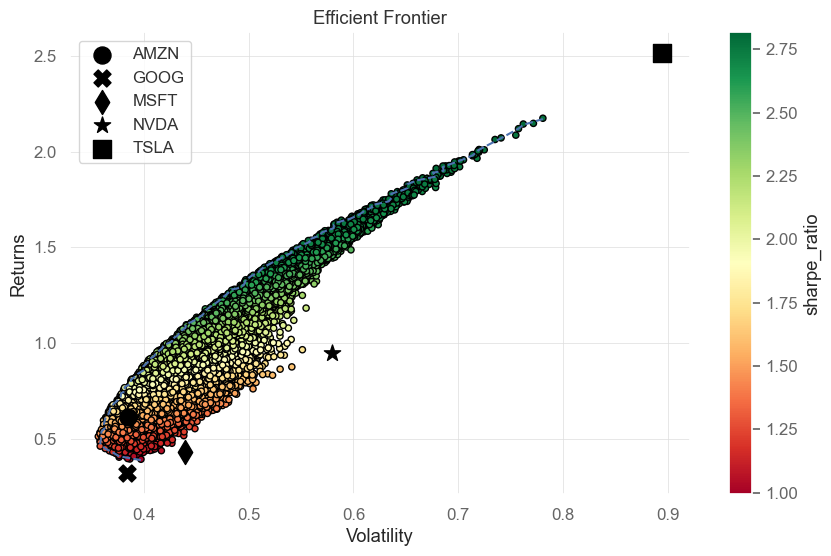

In [34]:
# 9. 효율적 경계선 시각화
import matplotlib.pyplot as plt

MARKS = ['o', 'X', 'd', '*', 's']

fig, ax = plt.subplots()
portf_results_df.plot(kind='scatter', x='volatility', y='returns', c='sharpe_ratio', cmap='RdYlGn', edgecolors='black', ax=ax)

ax.set(xlabel='Volatility', ylabel='Returns', title='Efficient Frontier')
ax.plot(portf_vol_ef, portf_rtns_ef, 'b--')

for asset_index in range(n_assets):
    ax.scatter(x=np.sqrt(cov_mat.iloc[asset_index, asset_index]),
               y=avg_returns[asset_index],
               marker=MARKS[asset_index],
               s=150,
               color='black',
               label=RISKY_ASSETS[asset_index])

ax.legend()
